# Previsão de Demanda - Questão 7

## Objetivo
Construir um modelo baseline de **média móvel de 7 dias** para prever a demanda diária do produto *Motor de Popa Yamaha Evo Dash 155HP* (`id_product = 54`) no mês de janeiro de 2024.

## Premissas
- **Período de treino:** dados até 31/12/2023
- **Período de teste:** janeiro de 2024 (01/01 a 31/01)
- **Granularidade:** previsão diária
- **Modelo baseline:** média móvel simples dos 7 dias anteriores
- **Sem vazamento de dados:** nenhum dado futuro é utilizado no treino ou na previsão

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Carregamento e Tratamento dos Dados

In [2]:
df = pd.read_csv('../datasets/vendas_2023_2024.csv')

df['sale_date'] = pd.to_datetime(df['sale_date'], format='mixed', dayfirst=True)

print(f"Dataset carregado: {df.shape[0]} registros, {df.shape[1]} colunas")
print(f"Periodo: {df['sale_date'].min().strftime('%d/%m/%Y')} a {df['sale_date'].max().strftime('%d/%m/%Y')}")
df.head()

Dataset carregado: 9895 registros, 6 colunas
Periodo: 01/01/2023 a 31/12/2024


,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,2024-09-15
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


## 2. Filtragem do Produto e Agregação Diária

Filtramos apenas o produto `id_product = 54` (Motor de Popa Yamaha Evo Dash 155HP) e agregamos a quantidade vendida por dia.

In [3]:
df_produto = df[df['id_product'] == 54].copy()

print(f"Registros de vendas do produto 54: {len(df_produto)}")
print(f"Dias unicos com vendas: {df_produto['sale_date'].dt.date.nunique()}")

vendas_diarias = df_produto.groupby('sale_date')['qtd'].sum().reset_index()
vendas_diarias.columns = ['data', 'qtd_vendida']
vendas_diarias = vendas_diarias.sort_values('data').reset_index(drop=True)

print(f"\nResumo das vendas diarias agregadas:")
vendas_diarias.head(10)

Registros de vendas do produto 54: 62
Dias unicos com vendas: 58

Resumo das vendas diarias agregadas:


,data,qtd_vendida
0,2023-01-10,3
1,2023-02-06,13
2,2023-02-27,15
3,2023-03-04,14
4,2023-03-15,4
5,2023-03-22,9
6,2023-04-07,7
7,2023-04-11,15
8,2023-04-21,4
9,2023-05-16,13


## 3. Criação do Calendário Completo

Para garantir que dias sem vendas sejam tratados como demanda zero, criamos um calendário contínuo de 01/01/2023 a 31/01/2024 e preenchemos os dias ausentes com 0.

In [4]:
calendario = pd.date_range(start='2023-01-01', end='2024-01-31', freq='D')
df_calendario = pd.DataFrame({'data': calendario})

df_completo = df_calendario.merge(vendas_diarias, on='data', how='left')
df_completo['qtd_vendida'] = df_completo['qtd_vendida'].fillna(0).astype(int)

print(f"Calendario completo: {len(df_completo)} dias")
print(f"Dias com vendas > 0: {(df_completo['qtd_vendida'] > 0).sum()}")
print(f"Dias sem vendas: {(df_completo['qtd_vendida'] == 0).sum()}")
print(f"\nUltimos 10 dias de dezembro de 2023:")
print(df_completo[(df_completo['data'] >= '2023-12-22') & (df_completo['data'] <= '2023-12-31')].to_string(index=False))

Calendario completo: 396 dias
Dias com vendas > 0: 30
Dias sem vendas: 366

Ultimos 10 dias de dezembro de 2023:
      data  qtd_vendida
2023-12-22            0
2023-12-23            0
2023-12-24            0
2023-12-25            0
2023-12-26            0
2023-12-27            0
2023-12-28            0
2023-12-29            0
2023-12-30            0
2023-12-31            0


## 4. Divisão Treino / Teste

- **Treino:** até 31/12/2023
- **Teste:** 01/01/2024 a 31/01/2024

In [5]:
data_corte = pd.Timestamp('2023-12-31')

df_treino = df_completo[df_completo['data'] <= data_corte].copy()
df_teste = df_completo[df_completo['data'] > data_corte].copy()

print(f"Periodo de treino: {df_treino['data'].min().strftime('%d/%m/%Y')} a {df_treino['data'].max().strftime('%d/%m/%Y')} ({len(df_treino)} dias)")
print(f"Periodo de teste:  {df_teste['data'].min().strftime('%d/%m/%Y')} a {df_teste['data'].max().strftime('%d/%m/%Y')} ({len(df_teste)} dias)")

Periodo de treino: 01/01/2023 a 31/12/2023 (365 dias)
Periodo de teste:  01/01/2024 a 31/01/2024 (31 dias)


## 5. Modelo Baseline: Média Móvel de 7 Dias

Para cada dia T no período de teste, a previsão é calculada como a média dos valores **reais** dos 7 dias anteriores (T-7 a T-1). A abordagem rolling utiliza sempre dados observados, sem incorporar previsões anteriores, evitando assim qualquer tipo de vazamento de dados.

In [6]:
serie_completa = df_completo.set_index('data')['qtd_vendida']

previsoes = []

for data_teste in df_teste['data']:
    janela_inicio = data_teste - pd.Timedelta(days=7)
    janela_fim = data_teste - pd.Timedelta(days=1)
    
    valores_janela = serie_completa[janela_inicio:janela_fim]
    previsao = valores_janela.mean()
    
    previsoes.append({
        'data': data_teste,
        'real': serie_completa[data_teste],
        'previsao': previsao
    })

df_resultado = pd.DataFrame(previsoes)

print("Resultado da previsao - Janeiro 2024:")
print(df_resultado.to_string(index=False))

Resultado da previsao - Janeiro 2024:
      data  real  previsao
2024-01-01     0  0.000000
2024-01-02     0  0.000000
2024-01-03     0  0.000000
2024-01-04     0  0.000000
2024-01-05     0  0.000000
2024-01-06     0  0.000000
2024-01-07     0  0.000000
2024-01-08     0  0.000000
2024-01-09     0  0.000000
2024-01-10     0  0.000000
2024-01-11     0  0.000000
2024-01-12     0  0.000000
2024-01-13     0  0.000000
2024-01-14     0  0.000000
2024-01-15     0  0.000000
2024-01-16     0  0.000000
2024-01-17     0  0.000000
2024-01-18     0  0.000000
2024-01-19     0  0.000000
2024-01-20     0  0.000000
2024-01-21    11  0.000000
2024-01-22     6  1.571429
2024-01-23     0  2.428571
2024-01-24     0  2.428571
2024-01-25     0  2.428571
2024-01-26     0  2.428571
2024-01-27     0  2.428571
2024-01-28     0  2.428571
2024-01-29     0  0.857143
2024-01-30     0  0.000000
2024-01-31     0  0.000000


## 6. Avaliação do Modelo: MAE

In [7]:
mae = mean_absolute_error(df_resultado['real'], df_resultado['previsao'])

print("=" * 50)
print("AVALIACAO DO MODELO BASELINE")
print("=" * 50)
print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"\nDemanda real total em janeiro/2024: {df_resultado['real'].sum():.0f} unidades")
print(f"Demanda prevista total em janeiro/2024: {df_resultado['previsao'].sum():.2f} unidades")

AVALIACAO DO MODELO BASELINE
MAE (Mean Absolute Error): 1.00

Demanda real total em janeiro/2024: 17 unidades
Demanda prevista total em janeiro/2024: 17.00 unidades


## 7. Validação - Soma das Previsões da Primeira Semana (Questão 7.2)

In [8]:
semana1 = df_resultado[(df_resultado['data'] >= '2024-01-01') & (df_resultado['data'] <= '2024-01-07')]

soma_previsoes_semana1 = semana1['previsao'].sum()

print("=" * 50)
print("VALIDACAO - QUESTAO 7.2")
print("=" * 50)
print(f"\nPrevisoes para a primeira semana de janeiro/2024:")
print(semana1[['data', 'real', 'previsao']].to_string(index=False))
print(f"\nSoma das previsoes (01/01 a 07/01): {soma_previsoes_semana1:.2f}")
print(f"Soma arredondada (inteiro): {round(soma_previsoes_semana1)}")

VALIDACAO - QUESTAO 7.2

Previsoes para a primeira semana de janeiro/2024:
      data  real  previsao
2024-01-01     0       0.0
2024-01-02     0       0.0
2024-01-03     0       0.0
2024-01-04     0       0.0
2024-01-05     0       0.0
2024-01-06     0       0.0
2024-01-07     0       0.0

Soma das previsoes (01/01 a 07/01): 0.00
Soma arredondada (inteiro): 0


## 8. Visualização: Real vs Previsto - Janeiro 2024

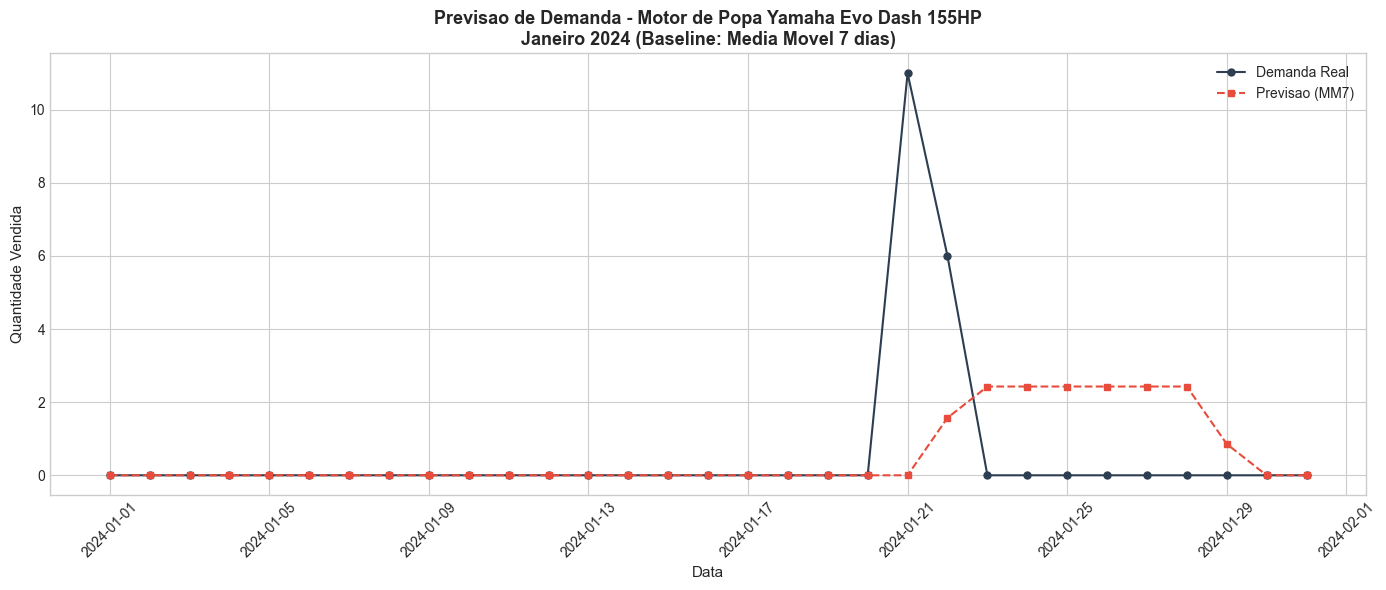

Grafico salvo em: ../outputs/graficos/07_previsao_demanda_jan2024.png


In [9]:
os.makedirs('../outputs/graficos', exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_resultado['data'], df_resultado['real'], marker='o', linewidth=1.5,
        markersize=5, label='Demanda Real', color='#2c3e50')
ax.plot(df_resultado['data'], df_resultado['previsao'], marker='s', linewidth=1.5,
        markersize=5, label='Previsao (MM7)', color='#e74c3c', linestyle='--')

ax.set_title('Previsao de Demanda - Motor de Popa Yamaha Evo Dash 155HP\nJaneiro 2024 (Baseline: Media Movel 7 dias)', fontsize=13, fontweight='bold')
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Quantidade Vendida', fontsize=11)
ax.legend(fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/graficos/07_previsao_demanda_jan2024.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo em: ../outputs/graficos/07_previsao_demanda_jan2024.png")

## 9. Interpretação dos Resultados (Questão 7.3)

### A. Como o baseline foi construído

Para cada dia T no período de teste (janeiro de 2024), a previsão foi calculada como a **média aritmética dos 7 dias anteriores** (T-7 a T-1). Foi criado um calendário completo de 01/01/2023 a 31/01/2024, preenchendo dias sem registros de venda com valor 0. Dessa forma, o modelo considera explicitamente que a ausência de venda em um dia equivale a demanda zero.

### B. Como o vazamento de dados foi evitado

O período de treino utiliza exclusivamente dados até 31/12/2023. Cada previsão no período de teste é calculada utilizando **somente os valores reais dos 7 dias imediatamente anteriores**. Para o dia 01/01/2024, por exemplo, utilizam-se os valores de 25/12 a 31/12/2023. Para o dia 02/01/2024, utilizam-se os valores de 26/12/2023 a 01/01/2024 (valor real observado). Em nenhum momento são utilizados dados futuros para gerar previsões.

### C. Limitação do modelo

O produto apresenta **demanda intermitente**: as vendas ocorrem em poucos dias ao longo do período analisado, com longos intervalos sem nenhuma venda. A média móvel de 7 dias retorna zero na maioria das previsões, pois a janela raramente contém dias com vendas. O modelo somente reage à demanda **após** ela ocorrer, com um atraso de até 7 dias, o que o torna inadequado para esse padrão de consumo. Para demanda intermitente, métodos como **Croston** ou **SBA (Syntetos-Boylan Approximation)** seriam mais apropriados, pois modelam separadamente a frequência e o tamanho da demanda.

In [10]:
print("=" * 50)
print("RESUMO FINAL")
print("=" * 50)
print(f"Produto: Motor de Popa Yamaha Evo Dash 155HP (id_product = 54)")
print(f"Modelo: Media Movel Simples - 7 dias")
print(f"MAE: {mae:.2f}")
print(f"Soma previsoes semana 1 (Jan 1-7): {round(soma_previsoes_semana1)}")
print(f"\nConclusao: O baseline de media movel de 7 dias e inadequado")
print(f"para este produto devido ao padrao de demanda intermitente.")

RESUMO FINAL
Produto: Motor de Popa Yamaha Evo Dash 155HP (id_product = 54)
Modelo: Media Movel Simples - 7 dias
MAE: 1.00
Soma previsoes semana 1 (Jan 1-7): 0

Conclusao: O baseline de media movel de 7 dias e inadequado
para este produto devido ao padrao de demanda intermitente.
